In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data

In [7]:
results_raw = pd.read_csv("results.csv").drop('Unnamed: 0', axis=1)
results = results_raw[results_raw["data_analysis"] == "real_only"]
results

,symbol,data,data_weights,model_name,val_mse,test_mse,test_mae,test_mape
0,BTC,real_only,NaN,LSTM,0.001495,0.001140,0.023474,3.217809
1,BTC,real_only,NaN,BD_LSTM,0.001486,0.001139,0.023435,3.223540
2,BTC,real_only,NaN,TCN,0.005709,0.005128,0.060011,8.029217
3,ETH,real_only,NaN,LSTM,0.001889,0.002188,0.032648,4.541128
4,ETH,real_only,NaN,BD_LSTM,0.001882,0.002159,0.032272,4.513619
5,ETH,real_only,NaN,TCN,0.003060,0.003513,0.044759,6.114533
6,XRP,real_only,NaN,LSTM,0.002108,0.001235,0.025229,5.248594
7,XRP,real_only,NaN,BD_LSTM,0.002108,0.001209,0.024727,5.128780
8,XRP,real_only,NaN,TCN,0.003823,0.002777,0.041048,8.145437


# Best model

In [11]:
results["rank"] = (
        results.groupby("symbol")["test_mse"]
        .rank(ascending=True, method="min")
        .astype(int)
    )
rank_per_model = results.groupby("model_name")["rank"].sum()
rank_per_model

model_name
BD_LSTM    3
LSTM       6
TCN        9
Name: rank, dtype: int64

In [13]:
mape_per_model = results.groupby("model_name")["test_mape"].mean()
mape_per_model

model_name
BD_LSTM    4.288646
LSTM       4.335844
TCN        7.429729
Name: test_mape, dtype: float64

# Model x Cryptocurrency heatmap

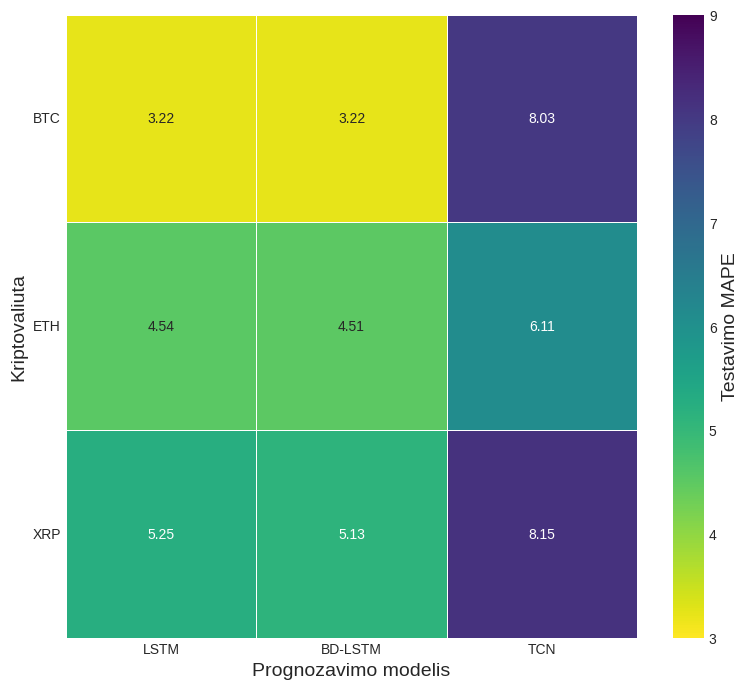

In [37]:
results["model_name"] = results["model_name"].replace({
    "BD_LSTM": "BD-LSTM"
})
model_order = ["LSTM", "BD-LSTM", "TCN"]

heatmap_df = results.pivot_table(
    index="symbol",
    columns="model_name",
    values="test_mape"
).reindex(columns=model_order)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap="viridis_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    vmin=3,
    vmax=9,
    cbar_kws={"label": "Testavimo MAPE"}
)
cbar = ax.figure.axes[-1]
cbar.yaxis.label.set_size(14)

ax.set_xlabel("Prognozavimo modelis", fontsize=14)
ax.set_ylabel("Kriptovaliuta", fontsize=14)

plt.yticks(rotation=0)
plt.tight_layout()